# 2×2 Ablation Study: D-CLAHE × PFT

**Fairness rules:**
- Standard models (1 & 3): identical schedule — 3-epoch linear LR warmup (1e-5→1e-3) + CosineDecay for 17 epochs, then 5 clean epochs at 1e-4 (BN frozen)
- PFT models (2 & 4): identical stage LRs — S1: 5e-4, S2: 1e-4, S3: 2e-5; 5+15+5 = 25 total epochs
- Both Standard and PFT have 25 total training epochs


In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import math
from google.colab import drive
import sys

drive.mount('/content/drive', force_remount=True)
sys.path.append('/content/drive/MyDrive/DCLAHE_MobileNetV3')

!unzip -n -q /content/drive/MyDrive/DCLAHE_MobileNetV3/cassavadata.zip -d /content/local_dataset

DATA_DIR = '/content/local_dataset'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.3, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.3, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')


val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds)}")

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Classes ({NUM_CLASSES}): {class_names}")

spatial_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=123),
    layers.RandomRotation(factor=0.25, seed=123),
    layers.RandomZoom(height_factor=(-0.2, 0.2), width_factor=(-0.2, 0.2), seed=123),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1, seed=123),
], name='spatial_aug')

train_ds = train_ds.map(lambda x, y: (spatial_aug(x, training=True), y),
                        num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)
batches_per_epoch = len(train_ds)
print(f"Batches/epoch: {batches_per_epoch}")


Mounted at /content/drive
Found 4802 files belonging to 5 classes.
Using 3362 files for training.
Found 4802 files belonging to 5 classes.
Using 1440 files for validation.
Validation batches: 45
Test batches: 45
Classes (5): ['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___healthy', 'Cassava_mosaic_disease', 'cassava_green_mottle']
Batches/epoch: 211


In [2]:
# ==============================================================================
# SYNTHETIC DEGRADATION
# ==============================================================================
@tf.function
def apply_random_shadow(image):
    # Smooth Gaussian Shadow (Cloud/Canopy shadow)
    H = tf.shape(image)[0]; W = tf.shape(image)[1]
    H_f = tf.cast(H, tf.float32); W_f = tf.cast(W, tf.float32)
    cy = tf.random.uniform([], 0.2, 0.8) * H_f
    cx = tf.random.uniform([], 0.2, 0.8) * W_f
    r = tf.random.uniform([], 0.15, 0.4) * tf.minimum(H_f, W_f)
    yy = tf.cast(tf.range(H), tf.float32); xx = tf.cast(tf.range(W), tf.float32)
    d = (tf.einsum('i,j->ij', ((yy-cy)/r)**2, tf.ones_like(xx)) +
         tf.einsum('i,j->ij', tf.ones_like(yy), ((xx-cx)/r)**2))
    # Smooth mask using Gaussian falloff
    mask = tf.expand_dims(tf.exp(-d * 2.0), -1)
    return image * (1.0 - mask * tf.random.uniform([], 0.4, 0.8))

@tf.function
def apply_random_glare(image):
    H = tf.shape(image)[0]; W = tf.shape(image)[1]
    H_f = tf.cast(H, tf.float32); W_f = tf.cast(W, tf.float32)
    cy = tf.random.uniform([], 0.2, 0.8)*H_f; cx = tf.random.uniform([], 0.2, 0.8)*W_f
    r = tf.random.uniform([], 0.05, 0.25) * tf.minimum(H_f, W_f)
    yy = tf.cast(tf.range(H), tf.float32); xx = tf.cast(tf.range(W), tf.float32)
    d = (tf.einsum('i,j->ij', ((yy-cy)/r)**2, tf.ones_like(xx)) +
         tf.einsum('i,j->ij', tf.ones_like(yy), ((xx-cx)/r)**2))
    return tf.clip_by_value(image + tf.expand_dims(tf.exp(-d*2.0), -1)*tf.random.uniform([],0.2,0.5)*255.0, 0.0, 255.0)

@tf.function
def apply_random_gamma(image):
    return tf.pow(tf.maximum(image/255.0, 1e-7), tf.random.uniform([], 0.5, 2.0)) * 255.0

@tf.function
def apply_synthetic_degradation(image):
    image = tf.cast(image, tf.float32)
    image = tf.cond(tf.random.uniform([]) < 0.5, lambda: apply_random_gamma(image), lambda: image)
    image = tf.cond(tf.random.uniform([]) < 0.5, lambda: apply_random_shadow(image), lambda: image)
    image = tf.cond(tf.random.uniform([]) < 0.4, lambda: apply_random_glare(image), lambda: image)
    return image

train_ds_degraded = train_ds.map(
    lambda x, y: (tf.map_fn(apply_synthetic_degradation, x, fn_output_signature=tf.float32), y),
    num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

# ── MIXED DATASET: 50% clean + 50% degraded per image ──────────────────────
# Both models train on this identical dataset for fair comparison.
# The degradation is applied randomly per-image, so each batch naturally
# contains a mix of clean and degraded samples.
@tf.function
def maybe_degrade(image):
    return tf.cond(tf.random.uniform([]) < 0.5,
                   lambda: apply_synthetic_degradation(image),
                   lambda: tf.cast(image, tf.float32))

train_ds_mixed = train_ds.map(
    lambda x, y: (tf.map_fn(maybe_degrade, x, fn_output_signature=tf.float32), y),
    num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

# ── FIXED MIXED VALIDATION SET (deterministic, not re-randomized each epoch) ──
# Pre-collect all val images into memory, apply degradation once with a fixed seed.
# This eliminates epoch-to-epoch noise in the validation signal caused by
# re-randomizing which images get degraded on every evaluation call.
_val_images, _val_labels = [], []
for _imgs, _lbls in val_ds:
    _val_images.append(_imgs.numpy())
    _val_labels.append(_lbls.numpy())
_val_images = np.concatenate(_val_images, axis=0)
_val_labels = np.concatenate(_val_labels, axis=0)

# Apply degradation to exactly 50% of validation images using a fixed numpy seed
import numpy as np
_rng = np.random.RandomState(42)
_degrade_mask = _rng.rand(len(_val_images)) < 0.5
_val_images_mixed = _val_images.copy()
for _idx in range(len(_val_images)):
    if _degrade_mask[_idx]:
        _val_images_mixed[_idx] = apply_synthetic_degradation(
            tf.constant(_val_images[_idx])).numpy()

val_ds_mixed = tf.data.Dataset.from_tensor_slices(
    (_val_images_mixed.astype(np.float32), _val_labels)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


@tf.function
def degrade_deterministic(image):
    image = tf.pow(tf.cast(image, tf.float32)/255.0, 1.8)*255.0
    H = tf.shape(image)[0]; W = tf.shape(image)[1]
    H_f = tf.cast(H, tf.float32); W_f = tf.cast(W, tf.float32)
    yy = tf.cast(tf.range(H), tf.float32); xx = tf.cast(tf.range(W), tf.float32)

    # Smooth Shadow
    sy = 0.4*H_f; sx = 0.4*W_f; sr = 0.2*tf.minimum(H_f, W_f)
    sd = (tf.einsum('i,j->ij', ((yy-sy)/sr)**2, tf.ones_like(xx)) +
          tf.einsum('i,j->ij', tf.ones_like(yy), ((xx-sx)/sr)**2))
    shadow_mask = tf.expand_dims(tf.exp(-sd*2.0), -1)
    image = image * (1.0 - shadow_mask * 0.6)

    # Smooth Glare
    cy = 0.7*H_f; cx = 0.7*W_f; r = 0.15*tf.minimum(H_f, W_f)
    d = (tf.einsum('i,j->ij', ((yy-cy)/r)**2, tf.ones_like(xx)) +
         tf.einsum('i,j->ij', tf.ones_like(yy), ((xx-cx)/r)**2))
    return tf.clip_by_value(image + tf.expand_dims(tf.exp(-d*2.0),-1)*0.4*255.0, 0.0, 255.0)

val_ds_degraded = val_ds.map(
    lambda x, y: (tf.map_fn(degrade_deterministic, x, fn_output_signature=tf.float32), y),
    num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

print("Degradation pipelines ready.")


test_ds_degraded = test_ds.map(
    lambda x, y: (tf.map_fn(degrade_deterministic, x, fn_output_signature=tf.float32), y),
    num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


Degradation pipelines ready.


In [3]:
# ==============================================================================
# SHARED HELPERS
# ==============================================================================
from DClahe_Mobilenet import MobileNetV3Small as DClaheMobileNet

focal_loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0, label_smoothing=0.2)
HEAD_LAYER_NAMES = ['Conv_1', 'Conv_2', 'Logits']

# ── Warmup + CosineDecay LR schedule (used by BOTH Standard models) ──────────
# Identical schedule for fair comparison between Base Standard and D-CLAHE Standard
WARMUP_EPOCHS    = 3     # linear ramp from LR_MIN to LR_MAX
TOTAL_DEG_EPOCHS = 50    # total degraded-phase epochs (extended for equal 30-epoch budget)
LR_MAX_DEG       = 6e-4  # peak LR after warmup (lowered from 1e-3 to prevent D-CLAHE collapse)
LR_MIN_DEG       = 1e-5  # warmup start / cosine floor

def warmup_cosine_lr(epoch):
    """Linear warmup for epochs 0..WARMUP_EPOCHS-1, then cosine decay."""
    if epoch < WARMUP_EPOCHS:
        return LR_MIN_DEG + (LR_MAX_DEG - LR_MIN_DEG) * (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(TOTAL_DEG_EPOCHS - WARMUP_EPOCHS, 1)
    return LR_MIN_DEG + 0.5 * (LR_MAX_DEG - LR_MIN_DEG) * (1 + math.cos(math.pi * progress))

# ── PFT LR constants (used by BOTH PFT models) ──────────────────────────────
# Identical LRs for fair comparison between Base PFT and D-CLAHE PFT
PFT_LR_S1 = 1e-3   # Stage 1: head warmup (reverted -- higher LR benefits both Base and D-CLAHE PFT)
PFT_LR_S2 = 2e-4   # Stage 2: top-half backbone (reverted -- needed for D-CLAHE co-adaptation speed)
PFT_LR_S3 = 2e-5   # Stage 3: full network, clean data

# ── D-CLAHE helpers ──────────────────────────────────────────────────────────
def inject_weights(model):
    stock = tf.keras.applications.MobileNetV3Small(
        input_shape=(224,224,3), include_top=True, weights='imagenet')
    clean = lambda n: n.replace('/','').replace('_','').replace('-','').replace('batchnorm','bn').lower()
    user_map = {clean(l.name): l for l in model.layers}
    count = 0
    for sl in stock.layers:
        if clean(sl.name) in user_map:
            try: user_map[clean(sl.name)].set_weights(sl.get_weights()); count += 1
            except ValueError: pass
    print(f"  Transferred weights for {count} layers")
    del stock

@tf.function
def compute_anti_identity_loss(contrast_raw):
    contrast = tf.sigmoid(contrast_raw) * 2.5 + 0.2
        # 1. Spatial Variance Loss: Encourage *some* localized difference (target 0.1 instead of extreme 0.3)
    spatial_std = tf.math.reduce_std(contrast, axis=[1, 2])
    variance_loss = tf.reduce_mean(tf.maximum(0.0, 0.1 - spatial_std))

    # 2. Total Variation (TV) Loss: Force the 8x8 grid to be smooth so it doesn't create checkerboard artifacts
    tv_loss = tf.reduce_mean(tf.image.total_variation(contrast)) / 64.0

    return variance_loss + (0.5 * tv_loss)

def train_dclahe_epoch(model, dataset, optimizer, lambda_anti_id=0.05):
    loss_t = tf.keras.metrics.Mean()
    acc_t  = tf.keras.metrics.CategoricalAccuracy()
    est = model.get_layer('contrast_estimator')
    for images, labels in dataset:
        images = tf.cast(images, tf.float32)
        with tf.GradientTape() as tape:
            preds = model(images, training=True)
            cls   = focal_loss_fn(labels, preds)
            raw   = est(images / 255.0, training=True)
            aid   = compute_anti_identity_loss(raw[..., 0:1])
            total = cls + lambda_anti_id * aid
        grads = tape.gradient(total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        loss_t.update_state(total); acc_t.update_state(labels, preds)
    return loss_t.result().numpy(), acc_t.result().numpy()

def eval_model(model, dataset):
    acc = tf.keras.metrics.CategoricalAccuracy()
    for images, labels in dataset:
        acc.update_state(labels, model(images, training=False))
    return acc.result().numpy()

print("Helpers ready.")
print(f"LR schedule: warmup {WARMUP_EPOCHS} epochs ({LR_MIN_DEG:.0e} -> {LR_MAX_DEG:.0e}), then CosineDecay")
print(f"PFT LRs: S1={PFT_LR_S1:.0e}, S2={PFT_LR_S2:.0e}, S3={PFT_LR_S3:.0e}")


Helpers ready.
LR schedule: warmup 3 epochs (1e-05 -> 6e-04), then CosineDecay
PFT LRs: S1=1e-03, S2=2e-04, S3=2e-05


## Model 1: Base Model (Standard Training)
*Warmup + CosineDecay, 20 degraded + 5 clean epochs, BN frozen in Phase 2*


In [5]:
print("=" * 60)
print("--- Model 1: Base Model (Standard) ---")
print("=" * 60)
print(f"Schedule: {WARMUP_EPOCHS}-epoch warmup + CosineDecay | 50 epochs on mixed data (50% clean + 50% degraded)")

bb1 = tf.keras.applications.MobileNetV3Small(
    input_shape=(224,224,3), include_top=False, weights='imagenet', pooling='avg')
inp1 = layers.Input(shape=(224,224,3))
x1 = bb1(inp1)
x1 = layers.Dropout(0.4)(x1)
out1 = layers.Dense(NUM_CLASSES, activation='softmax', name='Predictions_Softmax')(x1)
model_base_std = models.Model(inp1, out1)

for layer in model_base_std.layers:
    layer.trainable = True

# ── Standard Training: 50 epochs on degraded data (degradation = data augmentation) ──
print("\nTraining: 50 epochs on mixed data (warmup + CosineDecay, checkpoint best)")
model_base_std.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_MIN_DEG),
    loss=focal_loss_fn, metrics=['accuracy'])

lr_scheduler_1 = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch, _: warmup_cosine_lr(epoch), verbose=0)

model_base_std.fit(
    train_ds_mixed, validation_data=val_ds_mixed, epochs=TOTAL_DEG_EPOCHS,
    callbacks=[
        lr_scheduler_1,
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=10, restore_best_weights=False),
        tf.keras.callbacks.ModelCheckpoint(
            'm1_best_deg.keras', monitor='val_accuracy', save_best_only=True,
            restore_best_weights=True)
    ])

print("Model 1 done.")


--- Model 1: Base Model (Standard) ---
Schedule: 3-epoch warmup + CosineDecay | 50 epochs on mixed data (50% clean + 50% degraded)

Training: 50 epochs on mixed data (warmup + CosineDecay, checkpoint best)
Epoch 1/50
211/211 [==============================] - 92s 292ms/step - loss: 0.2146 - accuracy: 0.4878 - val_loss: 0.2299 - val_accuracy: 0.4222 - lr: 2.0667e-04
Epoch 2/50
211/211 [==============================] - 61s 284ms/step - loss: 0.1720 - accuracy: 0.6591 - val_loss: 0.1975 - val_accuracy: 0.5764 - lr: 4.0333e-04
Epoch 3/50
211/211 [==============================] - 71s 335ms/step - loss: 0.1589 - accuracy: 0.7177 - val_loss: 0.2033 - val_accuracy: 0.6097 - lr: 6.0000e-04
Epoch 4/50
211/211 [==============================] - 61s 288ms/step - loss: 0.1498 - accuracy: 0.7653 - val_loss: 0.1594 - val_accuracy: 0.7486 - lr: 6.0000e-04
Epoch 5/50
211/211 [==============================] - 62s 291ms/step - loss: 0.1435 - accuracy: 0.7841 - val_loss: 0.1518 - val_accuracy: 0.7778 -

## Model 4: D-CLAHE Model (PFT Training)
*Same PFT LRs as Model 2 (S1: 5e-4, S2: 1e-4, S3: 2e-5) for fair comparison*


In [6]:
print("=" * 60)
print("--- Model 4: D-CLAHE Model (PFT) ---")
print("=" * 60)
print("PFT Strategy: Head -> Full+DCLAHE -> Clean Polish")

bb4 = DClaheMobileNet(
    input_shape=(224,224,3), include_top=False, pooling='avg',
    weights=None, dclahe_magnitude_reg_weight=0.02)
x4 = layers.Dropout(0.4)(bb4.output)
out4 = layers.Dense(NUM_CLASSES, activation='softmax', name='Predictions_Softmax')(x4)
model_enh_pft = models.Model(bb4.input, out4)
inject_weights(model_enh_pft)


# ── Stage 1: Head Only, 10 epochs (degraded, LR=1e-3) ─────────────────

# --- HYBRID RECONSTRUCTION LOSS SETUP ---
# Create paired dataset for Stage 1 (Degraded, Clean, Label)
train_ds_paired = train_ds.map(
    lambda x, y: (tf.map_fn(maybe_degrade, x, fn_output_signature=tf.float32), x, y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

# Create extractor to get D-CLAHE output during training
hybrid_extractor = tf.keras.Model(
    inputs=model_enh_pft.inputs,
    outputs=[model_enh_pft.output, model_enh_pft.get_layer('adaptive_contrast_layer').output]
)

def train_hybrid_epoch(model, extractor, dataset, optimizer, lambda_recon=0.0):
    epoch_cls_loss = tf.keras.metrics.Mean()
    epoch_recon_loss = tf.keras.metrics.Mean()
    epoch_acc = tf.keras.metrics.CategoricalAccuracy()

    for deg_img, clean_img, labels in dataset:
        with tf.GradientTape(persistent=True) as tape:
            preds, enh_img = extractor(deg_img, training=True)
            cls_loss = focal_loss_fn(labels, preds)

            # --- UNSUPERVISED ZERO-REFERENCE LOSS ---
            # 1. Exposure Loss: Force local 16x16 patches to average around 0.45 (optimal natural leaf lighting)
            patch_means = tf.nn.avg_pool2d(enh_img, ksize=16, strides=16, padding='VALID')
            # Hinge exposure loss: safe zone is [0.3, 0.7]
            exposure_loss = tf.reduce_mean(tf.square(tf.maximum(0.0, 0.3 - patch_means)) + tf.square(tf.maximum(0.0, patch_means - 0.7)))

            # 2. Local Contrast/Variance Loss: Force local patches to stretch their contrast (target std=0.2)
            patch_sq_means = tf.nn.avg_pool2d(tf.square(enh_img), ksize=16, strides=16, padding='VALID')
            patch_variance = patch_sq_means - tf.square(patch_means)
            std = tf.sqrt(tf.maximum(patch_variance, 1e-6))
            # Hinge variance loss: only penalize if std is below 0.10 (gentler on soft clean leaves)
            variance_loss = tf.reduce_mean(tf.square(tf.maximum(0.0, 0.10 - std)))

            # Multiply by 10.0 to give it strong learning signal
            unsup_loss = 10.0 * (exposure_loss + variance_loss)

        # Explicitly Decouple Gradients to prevent Adversarial Noise from the backbone!
        head_vars = model.get_layer('Conv_1').trainable_variables + model.get_layer('Predictions_Softmax').trainable_variables
        dclahe_vars = model.get_layer('contrast_estimator').trainable_variables

        grads_head = tape.gradient(cls_loss, head_vars)
        grads_dclahe = tape.gradient(unsup_loss, dclahe_vars)
        del tape

        # Apply gradients
        optimizer.apply_gradients(zip(grads_head + grads_dclahe, head_vars + dclahe_vars))

        epoch_cls_loss.update_state(cls_loss)
        epoch_recon_loss.update_state(unsup_loss) # Log the unsup loss here
        epoch_acc.update_state(labels, preds)

    return epoch_cls_loss.result().numpy(), epoch_acc.result().numpy(), epoch_recon_loss.result().numpy()

def evaluate_epoch(model, dataset, focal_loss_fn):
    epoch_cls_loss = tf.keras.metrics.Mean()
    epoch_acc = tf.keras.metrics.CategoricalAccuracy()
    for x_b, y_b in dataset:
        preds = model(x_b, training=False)
        loss = focal_loss_fn(y_b, preds)
        epoch_cls_loss.update_state(loss)
        epoch_acc.update_state(y_b, preds)
    return epoch_cls_loss.result().numpy(), epoch_acc.result().numpy()

print("\nStage 1A: D-CLAHE Warmup (5 epochs, Unsupervised Loss ONLY)")
for layer in model_enh_pft.layers: layer.trainable = False
model_enh_pft.get_layer('contrast_estimator').trainable = True
model_enh_pft.get_layer('adaptive_contrast_layer').trainable = True
opt4a_1 = tf.keras.optimizers.Adam(learning_rate=1e-3)
for epoch in range(5):
    t_cls, t_acc, t_unsup = train_hybrid_epoch(model_enh_pft, hybrid_extractor, train_ds_paired, opt4a_1)
    # Head is frozen, so cls_loss doesn't affect anything, it's just tracked.
    print(f"  S1A E{epoch+1:02d}: L1_shadow_loss={t_unsup:.4f}")

print("\nStage 1B: Head Warmup (15 epochs, Stable D-CLAHE)")
for layer in model_enh_pft.layers: layer.trainable = False
model_enh_pft.get_layer('Conv_1').trainable = True
model_enh_pft.get_layer('Predictions_Softmax').trainable = True
opt4a_2 = tf.keras.optimizers.Adam(tf.keras.optimizers.schedules.CosineDecay(1e-3, 15*batches_per_epoch))
for epoch in range(15):
    t_cls, t_acc, t_unsup = train_hybrid_epoch(model_enh_pft, hybrid_extractor, train_ds_paired, opt4a_2)
    v_cls, v_acc = evaluate_epoch(model_enh_pft, val_ds_mixed, focal_loss_fn)
    print(f"  S1B E{epoch+1:02d}: train_acc={t_acc:.4f}, val_acc={v_acc:.4f}")

# ── Stage 2: Full Backbone + D-CLAHE, 35 epochs (degraded, LR=2e-4) ────────
print("\nStage 2: Full Backbone Bottlenecks (40 epochs, mixed, LR=5e-5, D-CLAHE frozen)")
for layer in model_enh_pft.layers:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
model_enh_pft.get_layer('contrast_estimator').trainable = False
model_enh_pft.get_layer('adaptive_contrast_layer').trainable = False
opt4c = tf.keras.optimizers.Adam(
    tf.keras.optimizers.schedules.CosineDecay(5e-5, 40*batches_per_epoch))
best_s2_val = 0
best_s2_weights = None
wait = 0
patience = 12

for epoch in range(40):
        # Standard classification training for Stage 2
    acc_m = tf.keras.metrics.CategoricalAccuracy()
    loss_m = tf.keras.metrics.Mean()
    for x_b, y_b in train_ds_mixed:
        with tf.GradientTape(persistent=True) as tape:
            preds = model_enh_pft(x_b, training=True)
            loss = focal_loss_fn(y_b, preds)
        grads = tape.gradient(loss, model_enh_pft.trainable_variables)
        opt4c.apply_gradients(zip(grads, model_enh_pft.trainable_variables))
        acc_m.update_state(y_b, preds)
        loss_m.update_state(loss)
    tl, ta = loss_m.result().numpy(), acc_m.result().numpy()
    va = eval_model(model_enh_pft, val_ds_mixed)

    star = ""
    if va > best_s2_val:
        best_s2_val = va
        best_s2_weights = model_enh_pft.get_weights()
        wait = 0
        star = " *"
    else:
        wait += 1
        star = f"  (patience {wait}/{patience})"

    print(f"  S2 E{epoch+1:02d}: train={ta:.4f}, val={va:.4f}{star}")
    if wait >= patience:
        print("  Early stopping.")
        break

if best_s2_weights is not None:
    model_enh_pft.set_weights(best_s2_weights)

# ── Stage 3: Clean Polish, 5 epochs (clean, LR=1e-6) ────────
print("\nStage 3: Global Fine-Tune & Micro-Tuning (25 epochs, Mixed Data)")
for layer in model_enh_pft.layers:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
model_enh_pft.get_layer('contrast_estimator').trainable = True
model_enh_pft.get_layer('adaptive_contrast_layer').trainable = True
opt4d_bb = tf.keras.optimizers.Adam(tf.keras.optimizers.schedules.CosineDecay(1e-5, 25*batches_per_epoch))
opt4d_dclahe = tf.keras.optimizers.Adam(learning_rate=1e-6)
best_s3_val = 0.0
patience_counter = 0
for epoch in range(25):
    epoch_cls_loss = tf.keras.metrics.Mean()
    epoch_acc = tf.keras.metrics.CategoricalAccuracy()
    for x_b, y_b in train_ds_mixed:
        with tf.GradientTape(persistent=True) as tape:
            preds = model_enh_pft(x_b, training=True)
            loss = focal_loss_fn(y_b, preds)
        bb_vars = [v for v in model_enh_pft.trainable_variables if 'contrast' not in v.name]
        dc_vars = model_enh_pft.get_layer('contrast_estimator').trainable_variables
        grads_bb = tape.gradient(loss, bb_vars)
        grads_dc = tape.gradient(loss, dc_vars)
        opt4d_bb.apply_gradients(zip(grads_bb, bb_vars))
        opt4d_dclahe.apply_gradients(zip(grads_dc, dc_vars))
        del tape
        epoch_cls_loss.update_state(loss)
        epoch_acc.update_state(y_b, preds)
    v_cls, v_acc = evaluate_epoch(model_enh_pft, val_ds_mixed, focal_loss_fn)
    if v_acc > best_s3_val:
        best_s3_val = v_acc
        patience_counter = 0
        model_enh_pft.save_weights('best_model4_stage3.h5')
        print(f"  S3 E{epoch+1:02d}: train={epoch_acc.result().numpy():.4f}, val={v_acc:.4f} *")
    else:
        patience_counter += 1
        print(f"  S3 E{epoch+1:02d}: train={epoch_acc.result().numpy():.4f}, val={v_acc:.4f}  (patience {patience_counter}/10)")
        if patience_counter >= 10:
            print("  Early stopping Stage 3.")
            break
model_enh_pft.load_weights('best_model4_stage3.h5')


--- Model 4: D-CLAHE Model (PFT) ---
PFT Strategy: Head -> Full+DCLAHE -> Clean Polish
10734624/10734624 [==============================] - 1s 0us/step
  Transferred weights for 124 layers

Stage 1: Head + D-CLAHE (20 epochs, mixed, LR=1e-3, D-CLAHE unfrozen)


  S1 E01: train_acc=0.4923, val_acc=0.5847 | L1_shadow_loss=0.0268 | bias_cont=0.0269, bias_bright=0.0441
  S1 E02: train_acc=0.5717, val_acc=0.6542 | L1_shadow_loss=0.0113 | bias_cont=0.0274, bias_bright=0.0450
  S1 E03: train_acc=0.6199, val_acc=0.6903 | L1_shadow_loss=0.0112 | bias_cont=0.0274, bias_bright=0.0459
  S1 E04: train_acc=0.6514, val_acc=0.7125 | L1_shadow_loss=0.0112 | bias_cont=0.0277, bias_bright=0.0472
  S1 E05: train_acc=0.6785, val_acc=0.7153 | L1_shadow_loss=0.0111 | bias_cont=0.0285, bias_bright=0.0486
  S1 E06: train_acc=0.6948, val_acc=0.6444 | L1_shadow_loss=0.0110 | bias_cont=0.0286, bias_bright=0.0490
  S1 E07: train_acc=0.6990, val_acc=0.7250 | L1_shadow_loss=0.0109 | bias_cont=0.0288, bias_bright=0.0498
  S1 E08: train_acc=0.7192, val_acc=0.6986 | L1_shadow_loss=0.0110 | bias_cont=0.0291, bias_bright=0.0510
  S1 E09: train_acc=0.7151, val_acc=0.6639 | L1_shadow_loss=0.0107 | bias_cont=0.0297, bias_bright=0.0516
  S1 E10: train_acc=0.7278, val_acc=0.7028 | L

## Final Evaluation


In [7]:
import numpy as np

print("=" * 90)
print("FINAL ABLATION STUDY RESULTS — BLIND TEST SET (15% Unseen Data)")
print("=" * 90)

def evaluate_full(model, dataset_clean, dataset_degraded, name):
    """Evaluate a model on both clean and degraded blind test data with full metrics."""
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

    results = {}
    for domain, dataset in [("Clean", dataset_clean), ("Degraded", dataset_degraded)]:
        all_preds = []
        all_labels = []
        for images, labels in dataset:
            preds = model(images, training=False)
            all_preds.extend(tf.argmax(preds, axis=1).numpy())
            all_labels.extend(tf.argmax(labels, axis=1).numpy())

        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)

        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        mcc = matthews_corrcoef(all_labels, all_preds)

        results[domain] = {
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "MCC": mcc
        }

    return results

# Evaluate both models on the BLIND test set
r1 = evaluate_full(model_base_std, test_ds, test_ds_degraded, "Model 1")
r4 = evaluate_full(model_enh_pft, test_ds, test_ds_degraded, "Model 4")

# ── Print the comprehensive comparison table ──
metrics = ["Accuracy", "Precision", "Recall", "F1", "MCC"]
header = f"{'Metric':<12} | {'M1 Clean':>10} | {'M4 Clean':>10} | {'Δ Clean':>9} | {'M1 Degraded':>13} | {'M4 Degraded':>13} | {'Δ Degraded':>12}"
print(header)
print("-" * len(header))

for m in metrics:
    m1c = r1["Clean"][m]
    m4c = r4["Clean"][m]
    m1d = r1["Degraded"][m]
    m4d = r4["Degraded"][m]
    dc = m4c - m1c
    dd = m4d - m1d

    if m == "MCC":
        print(f"{m:<12} | {m1c:>10.4f} | {m4c:>10.4f} | {dc:>+9.4f} | {m1d:>13.4f} | {m4d:>13.4f} | {dd:>+12.4f}")
    else:
        print(f"{m:<12} | {m1c*100:>9.2f}% | {m4c*100:>9.2f}% | {dc*100:>+8.2f}pp | {m1d*100:>12.2f}% | {m4d*100:>12.2f}% | {dd*100:>+11.2f}pp")

# ── Print the degradation robustness table ──
print("\n" + "=" * 70)
print("DEGRADATION ROBUSTNESS (Clean → Degraded Drop)")
print("=" * 70)
print(f"{'Model':<25} | {'Clean Acc':>10} | {'Degraded Acc':>13} | {'Drop':>9}")
print("-" * 65)

m1_drop = r1["Clean"]["Accuracy"] - r1["Degraded"]["Accuracy"]
m4_drop = r4["Clean"]["Accuracy"] - r4["Degraded"]["Accuracy"]

print(f"{'1. Base (Standard)':<25} | {r1['Clean']['Accuracy']*100:>9.2f}% | {r1['Degraded']['Accuracy']*100:>12.2f}% | {m1_drop*100:>8.2f}pp")
print(f"{'4. D-CLAHE (PFT)':<25} | {r4['Clean']['Accuracy']*100:>9.2f}% | {r4['Degraded']['Accuracy']*100:>12.2f}% | {m4_drop*100:>8.2f}pp")
print("-" * 65)

# Winner declarations
print(f"\n  Best Clean Accuracy:    {'Model 4 (D-CLAHE PFT)' if r4['Clean']['Accuracy'] > r1['Clean']['Accuracy'] else 'Model 1 (Base)'} ({max(r4['Clean']['Accuracy'], r1['Clean']['Accuracy'])*100:.2f}%)")
print(f"  Best Degraded Accuracy: {'Model 4 (D-CLAHE PFT)' if r4['Degraded']['Accuracy'] > r1['Degraded']['Accuracy'] else 'Model 1 (Base)'} ({max(r4['Degraded']['Accuracy'], r1['Degraded']['Accuracy'])*100:.2f}%)")
print(f"  Most Robust (Lowest Drop): {'Model 4 (D-CLAHE PFT)' if m4_drop < m1_drop else 'Model 1 (Base)'} ({min(m4_drop, m1_drop)*100:.2f}pp)")
print(f"  Best Degraded MCC:     {'Model 4 (D-CLAHE PFT)' if r4['Degraded']['MCC'] > r1['Degraded']['MCC'] else 'Model 1 (Base)'} ({max(r4['Degraded']['MCC'], r1['Degraded']['MCC']):.4f})")


FINAL ABLATION STUDY RESULTS — BLIND TEST SET (15% Unseen Data)
Metric       |   M1 Clean |   M4 Clean |   Δ Clean |   M1 Degraded |   M4 Degraded |   Δ Degraded
-------------------------------------------------------------------------------------------------
Accuracy     |     76.67% |     79.31% |    +2.64pp |        74.31% |        78.06% |       +3.75pp
Precision    |     79.68% |     80.81% |    +1.13pp |        77.95% |        79.74% |       +1.79pp
Recall       |     75.21% |     78.58% |    +3.37pp |        71.55% |        77.22% |       +5.67pp
F1           |     76.24% |     79.12% |    +2.88pp |        73.00% |        77.67% |       +4.67pp
MCC          |     0.7092 |     0.7413 |   +0.0321 |        0.6783 |        0.7263 |      +0.0481

DEGRADATION ROBUSTNESS (Clean → Degraded Drop)
Model                     |  Clean Acc |  Degraded Acc |      Drop
-----------------------------------------------------------------
1. Base (Standard)        |     76.67% |        74.31% |     

In [8]:
import time
import os
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

def evaluate_comprehensive(model, dataset, model_name):
    print("=" * 60)
    print(f"Comprehensive Evaluation: {model_name}")
    print("=" * 60)

    y_true = []
    y_pred = []

    # ── Inference Latency ──
    start_time = time.time()
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    end_time = time.time()

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ── Classification Metrics ──
    acc = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)

    specificities = []
    for i in range(len(cm)):
        TN = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        FP = np.sum(cm[:, i]) - cm[i, i]
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificities.append(spec)
    specificity_macro = np.mean(specificities)

    print(f"Accuracy:                  {acc*100:.2f}%")
    print(f"Precision (Macro):         {precision_macro*100:.2f}%")
    print(f"Recall (Macro):            {recall_macro*100:.2f}%")
    print(f"F1 Score (Macro):          {f1_macro*100:.2f}%")
    print(f"True Negative Rate (Spec): {specificity_macro*100:.2f}%")
    print(f"MCC:                       {mcc:.4f}")

    # ── Inference Performance ──
    num_samples = len(y_true)
    total_time_ms = (end_time - start_time) * 1000
    latency_per_image = total_time_ms / num_samples
    print(f"\nInference Latency:         {latency_per_image:.2f} ms/image")

    import tempfile
    tmp_path = tempfile.mktemp(suffix='.h5')
    model.save(tmp_path, include_optimizer=False)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    print(f"Model Size:                {size_mb:.2f} MB")

    def get_macs(model):
        from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph
        concrete = tf.function(lambda inputs: model(inputs))
        concrete_func = concrete.get_concrete_function([tf.TensorSpec([1, *model.input_shape[1:]])])
        frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
        with tf.Graph().as_default() as graph:
            tf.graph_util.import_graph_def(graph_def, name='')
            run_meta = tf.compat.v1.RunMetadata()
            opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
            opts['output'] = 'none' # Suppress stdout
            flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)
            if flops is not None:
                return flops.total_float_ops // 2
            return 0
    try:
        macs = get_macs(model)
        print(f"MACs:                      {macs:,}")
    except:
        print("MACs:                      (Could not compute)")
    print("\n")

print("\n" + "*"*80)
print("\n" + "*"*80)
print("COMPREHENSIVE THESIS METRICS (CLEAN TEST DATASET)")
print("*"*80)
evaluate_comprehensive(model_base_std, test_ds, "Model 1: Base (Standard) - CLEAN")
evaluate_comprehensive(model_enh_pft, test_ds, "Model 4: D-CLAHE (PFT) - CLEAN")

print("\n" + "*"*80)
print("COMPREHENSIVE THESIS METRICS (DEGRADED TEST DATASET)")
print("*"*80)
evaluate_comprehensive(model_base_std, test_ds_degraded, "Model 1: Base (Standard) - DEGRADED")
evaluate_comprehensive(model_enh_pft, test_ds_degraded, "Model 4: D-CLAHE (PFT) - DEGRADED")



********************************************************************************

********************************************************************************
COMPREHENSIVE THESIS METRICS (CLEAN TEST DATASET)
********************************************************************************
Comprehensive Evaluation: Model 1: Base (Standard) - CLEAN
Accuracy:                  77.64%
Precision (Macro):         80.71%
Recall (Macro):            75.97%
F1 Score (Macro):          77.26%
True Negative Rate (Spec): 94.22%
MCC:                       0.7201

Inference Latency:         14.20 ms/image


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model Size:                6.16 MB


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


MACs:                      57,171,163


Comprehensive Evaluation: Model 4: D-CLAHE (PFT) - CLEAN


...

Accuracy:                  79.72%
Precision (Macro):         81.19%
Recall (Macro):            78.65%
F1 Score (Macro):          79.33%
True Negative Rate (Spec): 94.79%
MCC:                       0.7464

Inference Latency:         11.03 ms/image
Model Size:                6.41 MB
MACs:                      98,698,124



********************************************************************************
COMPREHENSIVE THESIS METRICS (DEGRADED TEST DATASET)
********************************************************************************
Comprehensive Evaluation: Model 1: Base (Standard) - DEGRADED
Accuracy:                  73.61%
Precision (Macro):         77.29%
Recall (Macro):            70.98%
F1 Score (Macro):          72.37%
True Negative Rate (Spec): 93.14%
MCC:                       0.6700

Inference Latency:         14.27 ms/image


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model Size:                6.16 MB
MACs:                      57,171,163


Comprehensive Evaluation: Model 4: D-CLAHE (PFT) - DEGRADED


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Accuracy:                  78.19%
Precision (Macro):         79.97%
Recall (Macro):            77.33%
F1 Score (Macro):          77.78%
True Negative Rate (Spec): 94.41%
MCC:                       0.7283

Inference Latency:         10.28 ms/image
Model Size:                6.41 MB
MACs:                      98,698,124




Extracting D-CLAHE Preprocessing Layer from Model 4...

--- DEGRADED IMAGES ---


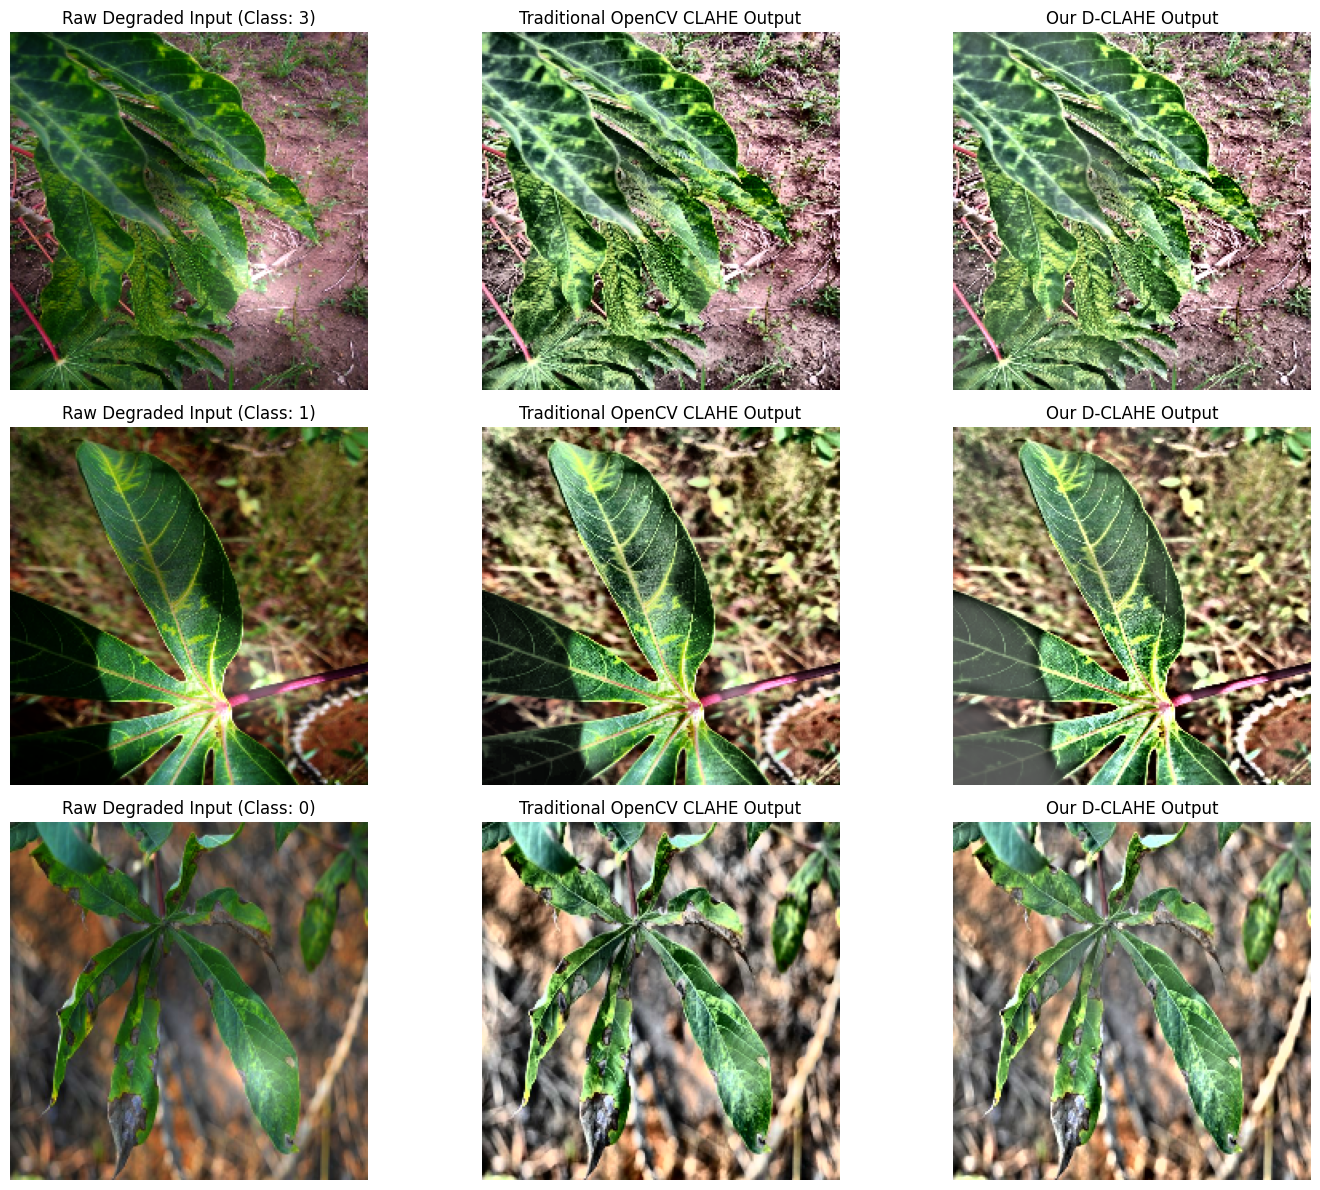


--- CLEAN IMAGES ---


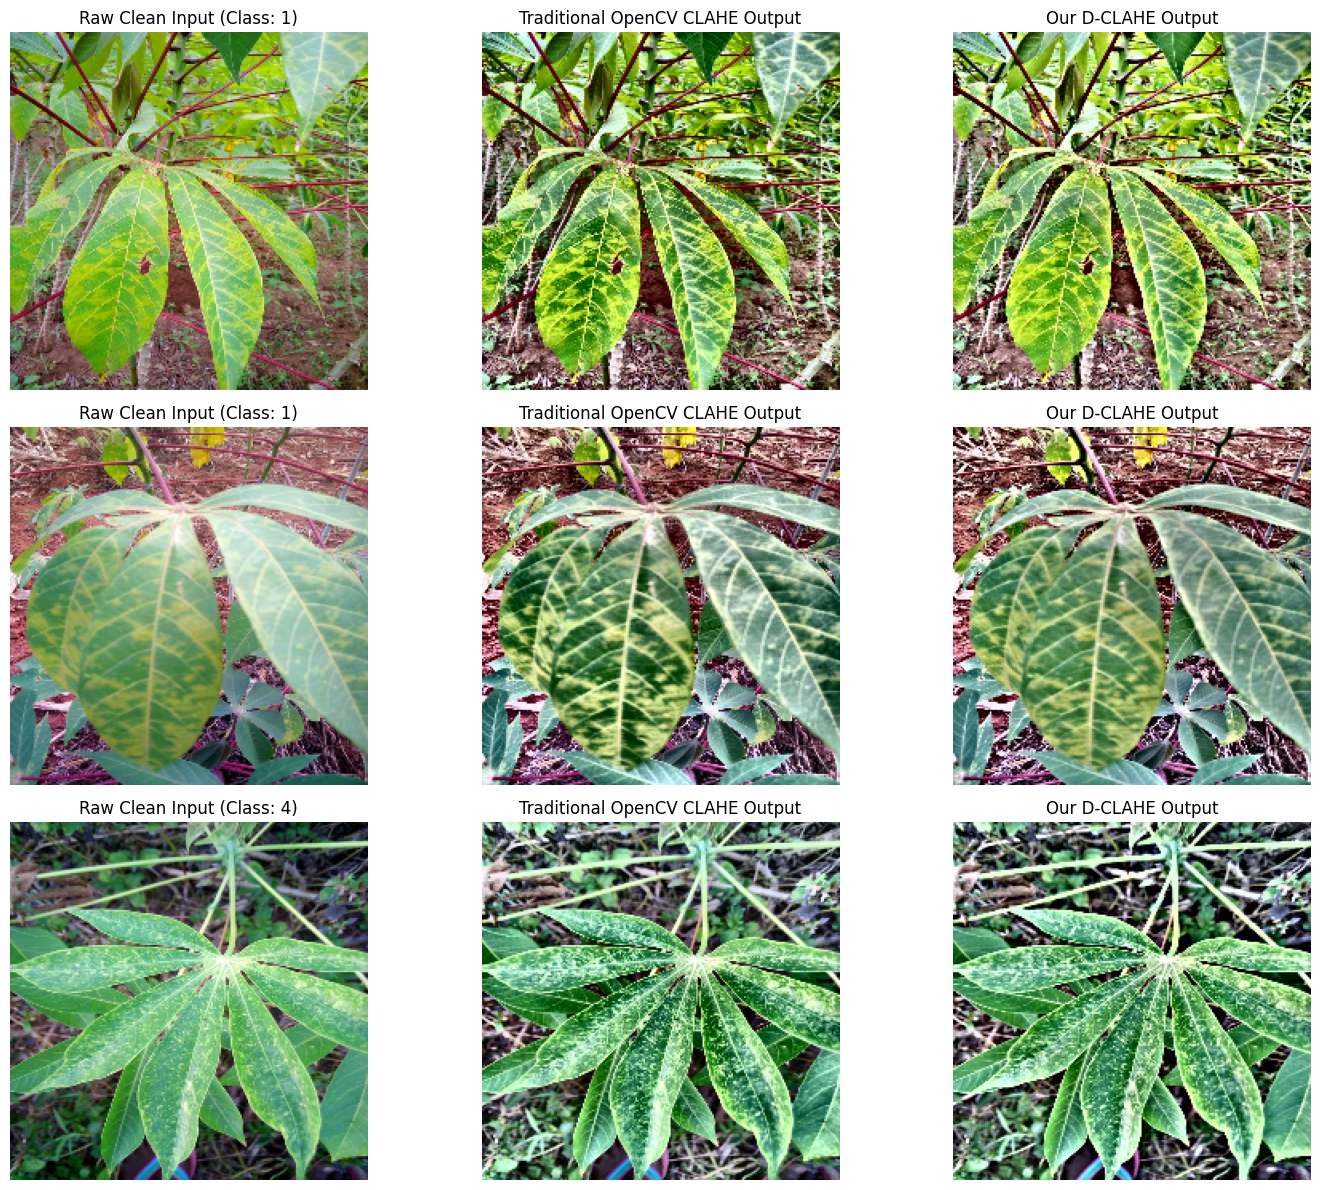

In [9]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_cv2_clahe(img_rgb):
    img_uint8 = img_rgb.astype(np.uint8)
    yuv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2YUV)
    clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
    yuv[:,:,0] = clahe.apply(yuv[:,:,0])
    rgb_out = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)
    return rgb_out / 255.0

print("Extracting D-CLAHE Preprocessing Layer from Model 4...")
dclahe_layer = None
for layer in model_enh_pft.layers:
    if 'adaptive_contrast' in layer.name:
        dclahe_layer = layer
        break

if dclahe_layer is not None:
    dclahe_visualizer = tf.keras.Model(inputs=model_enh_pft.input, outputs=dclahe_layer.output)

    print("\n--- DEGRADED IMAGES ---")
    for images, labels in val_ds_degraded.take(1):
        raw_images = images.numpy()
        enhanced_images = dclahe_visualizer.predict(raw_images, verbose=0)

        plt.figure(figsize=(15, 12))
        for i in range(3):
            # Raw Image
            plt.subplot(3, 3, 3*i + 1)
            plt.imshow(raw_images[i].astype(np.uint8))
            plt.title(f"Raw Degraded Input (Class: {np.argmax(labels[i])})")
            plt.axis('off')

            # OpenCV CLAHE
            plt.subplot(3, 3, 3*i + 2)
            plt.imshow(apply_cv2_clahe(raw_images[i]))
            plt.title("Traditional OpenCV CLAHE Output")
            plt.axis('off')

            # D-CLAHE
            plt.subplot(3, 3, 3*i + 3)
            plt.imshow(enhanced_images[i])
            plt.title("Our D-CLAHE Output")
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        break

    print("\n--- CLEAN IMAGES ---")
    for images, labels in val_ds.take(1):
        raw_images = images.numpy()
        enhanced_images = dclahe_visualizer.predict(raw_images, verbose=0)

        plt.figure(figsize=(15, 12))
        for i in range(3):
            # Raw Image
            plt.subplot(3, 3, 3*i + 1)
            plt.imshow(raw_images[i].astype(np.uint8))
            plt.title(f"Raw Clean Input (Class: {np.argmax(labels[i])})")
            plt.axis('off')

            # OpenCV CLAHE
            plt.subplot(3, 3, 3*i + 2)
            plt.imshow(apply_cv2_clahe(raw_images[i]))
            plt.title("Traditional OpenCV CLAHE Output")
            plt.axis('off')

            # D-CLAHE
            plt.subplot(3, 3, 3*i + 3)
            plt.imshow(enhanced_images[i])
            plt.title("Our D-CLAHE Output")
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        break
else:
    print("Could not locate D-CLAHE layer.")
